In [3]:
from pychiver.archiver import Archiver

### Easy data extraction

In [ ]:
archiver = Archiver(archiver_url='http://archiver-01.tn.esss.lu.se')
start = "2021-06-19 12:00:00"
end = "2021-06-20 12:00:00"
pvs = ("RFQ-010:RFS-Kly-110:Oil-Tmp", "RFQ-010:RFS-Kly-110:Coll-WtrC-Flw")
data = archiver.get(pvs, start_date=start, end_date=end, entries_limit=1000)

In [6]:
data['RFQ-010:RFS-Kly-110:Oil-Tmp']

,secs,val,nanos,severity,status,status_label,severity_label,secs_nanos,time
0,1624104088,39.700001,724461439,0,0,EpicsStatus.NO_ALARM,EpicsSeverity.NO_ALARM,1.624104e+09,2021-06-19 12:01:28.724461555
1,1624104089,39.599998,227933830,0,0,EpicsStatus.NO_ALARM,EpicsSeverity.NO_ALARM,1.624104e+09,2021-06-19 12:01:29.227933884
2,1624104090,39.700001,724081824,0,0,EpicsStatus.NO_ALARM,EpicsSeverity.NO_ALARM,1.624104e+09,2021-06-19 12:01:30.724081755
3,1624104091,39.599998,223751534,0,0,EpicsStatus.NO_ALARM,EpicsSeverity.NO_ALARM,1.624104e+09,2021-06-19 12:01:31.223751545
4,1624104092,39.700001,223704171,0,0,EpicsStatus.NO_ALARM,EpicsSeverity.NO_ALARM,1.624104e+09,2021-06-19 12:01:32.223704100
...,...,...,...,...,...,...,...,...,...
1378,1624190358,39.299999,973961868,0,0,EpicsStatus.NO_ALARM,EpicsSeverity.NO_ALARM,1.624190e+09,2021-06-20 11:59:18.973961830
1379,1624190360,39.200001,471338746,0,0,EpicsStatus.NO_ALARM,EpicsSeverity.NO_ALARM,1.624190e+09,2021-06-20 11:59:20.471338749
1380,1624190360,39.299999,972774081,0,0,EpicsStatus.NO_ALARM,EpicsSeverity.NO_ALARM,1.624190e+09,2021-06-20 11:59:20.972774029
1381,1624190361,39.200001,472603682,0,0,EpicsStatus.NO_ALARM,EpicsSeverity.NO_ALARM,1.624190e+09,2021-06-20 11:59:21.472603798


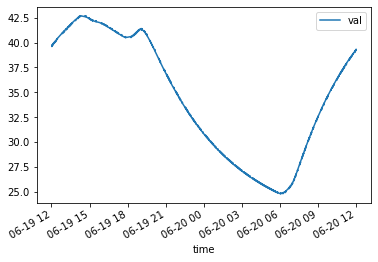

In [7]:
data['RFQ-010:RFS-Kly-110:Oil-Tmp'].plot(x='time', y='val')

### Get more PVs alligned with eachother

#### Simple align

the default interpolation strategy is `LinearIneterpolationStrategy` (see README.md for details)

In [8]:
data = archiver.getAligned(pvs, start_date=start, end_date=end)

/Users/arekgorzawski/opt/anaconda3/lib/python3.8/site-packages/pychiver/endpoints.py:103: UserWarning: You are about to extract 170968.0 samples, this operation may take significant amount of time...
  warnings.warn(


2


In [9]:
data

,secs_nanos,RFQ-010:RFS-Kly-110:Oil-Tmp:val,RFQ-010:RFS-Kly-110:Coll-WtrC-Flw:val,time
0,1.624104e+09,39.700001,230.821359,2021-06-19 12:01:28.724461555
1,1.624104e+09,39.599998,230.920710,2021-06-19 12:01:29.227933884
2,1.624104e+09,39.700001,231.417805,2021-06-19 12:01:30.724081755
3,1.624104e+09,39.599998,231.454335,2021-06-19 12:01:31.223751545
4,1.624104e+09,39.700001,231.588942,2021-06-19 12:01:32.223704100
...,...,...,...,...
1378,1.624190e+09,39.299999,231.607209,2021-06-20 11:59:18.973961830
1379,1.624190e+09,39.200001,230.822128,2021-06-20 11:59:20.471338749
1380,1.624190e+09,39.299999,231.823265,2021-06-20 11:59:20.972774029
1381,1.624190e+09,39.200001,231.292449,2021-06-20 11:59:21.472603798


#### Align with *customised interpolation strategy*

In [15]:
pvs = ("RFQ-010:RFS-Kly-110:PwrFwd-Wave-High",  # often archived PV
       "RFQ-010:RFS-EVR-101:DlyGen1-Width-RB", # less often archived PV
       "RFQ-010:RFS-EVR-101:CycleFreq-RB")     # even more less often archived PV

startTime = '2021-07-16 10:24:00'
endTime = '2021-07-16 14:00:00'

from pychiver.calculations import LastAcquiredValueInterpolationStrategy

data = archiver.getAligned(pvs, start_date=startTime, end_date=endTime, 
                           strategy=LastAcquiredValueInterpolationStrategy, 
                           entries_limit=(3000, None, None,))





/Users/arekgorzawski/opt/anaconda3/lib/python3.8/site-packages/pychiver/endpoints.py:103: UserWarning: You are about to extract 137637.0 samples, this operation may take significant amount of time...
  warnings.warn(


3


In [16]:
data

,secs_nanos,RFQ-010:RFS-Kly-110:PwrFwd-Wave-High:val,RFQ-010:RFS-EVR-101:DlyGen1-Width-RB:val,RFQ-010:RFS-EVR-101:CycleFreq-RB:val,time
0,1.626431e+09,776.866833,50.004259,1.999987,2021-07-16 10:24:00.909166813
1,1.626431e+09,776.451820,50.004259,3.999975,2021-07-16 10:24:26.160162449
2,1.626431e+09,775.870801,50.004259,3.999975,2021-07-16 10:24:37.416092396
3,1.626431e+09,778.111873,50.004259,5.999963,2021-07-16 10:24:47.827087164
4,1.626431e+09,768.151556,50.004259,5.999963,2021-07-16 10:24:55.326795816
...,...,...,...,...,...
3054,1.626444e+09,757.776226,3200.000000,13.999913,2021-07-16 13:59:44.610460281
3055,1.626444e+09,757.610221,3200.000000,13.999913,2021-07-16 13:59:47.824203491
3056,1.626444e+09,759.768290,3200.000000,13.999913,2021-07-16 13:59:51.038774252
3057,1.626444e+09,758.855261,3200.000000,13.999913,2021-07-16 13:59:54.966217279


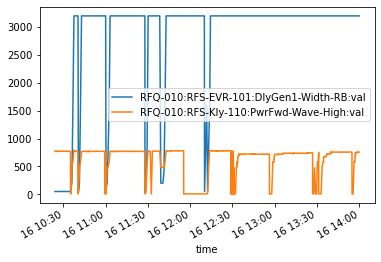

In [23]:
data.plot(x='time', y=['RFQ-010:RFS-EVR-101:DlyGen1-Width-RB:val', 'RFQ-010:RFS-Kly-110:PwrFwd-Wave-High:val'])

### PV Archiver status check

In [8]:
archiver.check('RFQ-010:RFS-Kly-110:Oil-Tmp')

{'RFQ-010:RFS-Kly-110:Oil-Tmp': {'lastRotateLogs': 'Never',
  'appliance': 'archiver-01',
  'pvName': 'RFQ-010:RFS-Kly-110:Oil-Tmp',
  'pvNameOnly': 'RFQ-010:RFS-Kly-110:Oil-Tmp',
  'connectionState': 'true',
  'lastEvent': 'Jun/24/2021 19:35:05 +02:00',
  'samplingPeriod': '0.07',
  'isMonitored': 'true',
  'connectionLastRestablished': 'Never',
  'connectionFirstEstablished': 'Jun/21/2021 12:20:38 +02:00',
  'connectionLossRegainCount': '0',
  'status': 'Being archived'}}